# Tracking the DM Wind

The sky position of the DM wind vector changes over the course of the year by several degrees. So, the time of "DM noon" and "DM midnight" varies with respect to sidereal time. 

In [1]:
import numpy as np
import sys
import math
import datetime as dts #for calendar functions
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, Galactic, ICRS
from astropy.coordinates import solar_system_ephemeris, EarthLocation
from astropy.coordinates import get_body_barycentric, get_body
from astropy.coordinates import CartesianRepresentation, CartesianDifferential

import scipy.optimize as sciop

import matplotlib.pyplot as plt
# import matplotlib.colors as clr

# sys.path.insert(0,'../') #load the local version
from earthspeed import *


In [2]:
sid_seconds = 86164.0905 # seconds per sidereal day

def getExtrema(location, t0, maxAlt=True, n_solns=1, as_datetime=False):
    """Returns list of "noon" or "midnight" times of max/min altitude.
    if maxAlt: returns a list of "DM noon" times where the altitude is maximized, 
        beginning with the first maximum after time t0, and including n_days many maxima
    if not maxAlt: finds "DM midnight" where the altitude is most negative
    if as_datetime: 
        returns list of noon/midnight times as datetime objects
    else:
        returns list of "DeltaT = noon - t0" in seconds.
    """

    minmax = 1
    if maxAlt:
        minmax = -1
    # get the altitude as function of time
    # multiply by (-1) to get the maximum from minimize_scalar
    def loc_alt(dt_secs):
        dt = dts.timedelta(seconds=dt_secs)
        vE, alt, az = vE_AltAz(t0+dt, location)
        return minmax * alt

    # find the first upcoming maximum: 
    minz = sciop.minimize_scalar(loc_alt, bounds=[0.0, sid_seconds])
    noon_0 = minz.x

    dt_noons = [noon_0]
    for n in range(1, n_solns):
        t_last = dt_noons[-1]
        t_guess = t_last + sid_seconds
        intv = 3e2 # greater than daily precession of the DM noon in sidereal time
        newn = sciop.minimize_scalar(loc_alt, bounds=[t_guess-intv, t_guess+intv])
        dt_noons += [newn.x]

    if as_datetime:
        noontimes = []
        for dt in dt_noons:
            noon = t0 + dts.timedelta(seconds=dt)
            noontimes += [noon]
        return noontimes

    # return [dt_noons[n] - n*sid_seconds for n in range(len(dt_noons))] 
    return dt_noons
#


In [3]:
### Places and Timezones:

# Penn State:
whitmore = EarthLocation(lat='40.7986', lon='-77.8635', height=0.*u.m)
# University of Oregon:
willamette = EarthLocation(lat='44.0459', lon='-123.07245', height=0.*u.m)
# Fermilab:
wilsonhall = EarthLocation(lat='41.8', lon='-88.3', height=0.*u.m)

pdt = dts.timezone(dts.timedelta(hours=-7), name='PDT') # Pacific daylight time
mdt = dts.timezone(dts.timedelta(hours=-6), name='MDT') # Mountain daylight time
cdt = dts.timezone(dts.timedelta(hours=-5), name='CDT') # Central daylight time
edt = dts.timezone(dts.timedelta(hours=-4), name='EDT') # Eastern daylight time
pst = dts.timezone(dts.timedelta(hours=-8), name='PST') # Pacific standard time
mst = dts.timezone(dts.timedelta(hours=-7), name='MST') # Mountain standard time
cst = dts.timezone(dts.timedelta(hours=-6), name='CST') # Central standard time
est = dts.timezone(dts.timedelta(hours=-5), name='EST') # Eastern standard time


## Simple Examples 
### Using vEt and datetime:

In [4]:
# Example: altitude and azimuth for a particular place on Earth

date = dts.datetime.now(dts.timezone.utc)
wind = Windfinder([date])
print('Example datetime (UTC):', date)
ra, dec = wind.RAdec[0]
print('Sky position: RA, dec [deg] = ({:.2f}, {:.2f})'.format(ra, dec))

altaz = wind.vE_altAz(willamette)
print('Willamette Hall, U.Oregon:')
print('\t vE [km/s]: {:.2f} \t alt [deg]: {:.2f} \t az [deg]: {:.2f}'.format(altaz[0][0], altaz[0][1], altaz[0][2]))

# Can also use astropy object Windfinder.galactic directly:
vE_icrs = wind.galactic[0].transform_to(ICRS())
vE_icrs.dec

Example datetime (UTC): 2026-01-05 15:10:51.607537+00:00
Sky position: RA, dec [deg] = (303.93, 49.15)
Willamette Hall, U.Oregon:
	 vE [km/s]: 239.93 	 alt [deg]: 29.45 	 az [deg]: 48.41


<Latitude 49.14736587 deg>

### Using earthspeed.now()

earthspeed.now() prints the current direction of the Earth velocity in RA and dec, with RA in degrees (default) or hours (if called with RA_hours=True).

Specifying a location is optional. This will print the local altitude and azimuth of vE. 

In [5]:
wind = now(location=whitmore, RA_hours=True)

DM wind location at 2026-01-05 15:10:52.395494+00:00 (UTC):
	RA = 20.262 [hour] 	dec = 49.147 [deg]
sky coordinates at Earth location (lat,lon) = (40.799, -77.863) [deg]:
	altitude = 54.978 [deg] 	azimuth = 59.236 [deg]


## Daily Variation: Altitude and Azimuth at a specific location

Finding the lab-frame dark matter wind on a particular day (Jan 1, 2026) and location (Whitmore Hall at Penn State).

In [6]:
lablocation = whitmore
midnight = dts.datetime(2026, 1, 1, hour=0, tzinfo=est)
midnight.astimezone(dts.timezone.utc)

datetime.datetime(2026, 1, 1, 5, 0, tzinfo=datetime.timezone.utc)

In [7]:
dt_hours = 0.25
dt = dt_hours * dts.timedelta(hours=1)
obstimes = [midnight + dt * j for j in range(24*4+1)]

tH = np.zeros(len(obstimes))
vEs = np.zeros(len(obstimes))
alts = np.zeros(len(obstimes))
azs = np.zeros(len(obstimes))

for j,time in enumerate(obstimes):
    vE, alt, az = vE_AltAz(time, wilsonhall)
    tH[j] = dt_hours*j 
    vEs[j] = vE
    alts[j] = alt
    azs[j] = az

print('altitude min and max: {:.2f}, {:.2f} [degrees]'.format( alts.min(), alts.max()))

#

altitude min and max: 1.53, 82.07 [degrees]


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_28426/2868926724.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


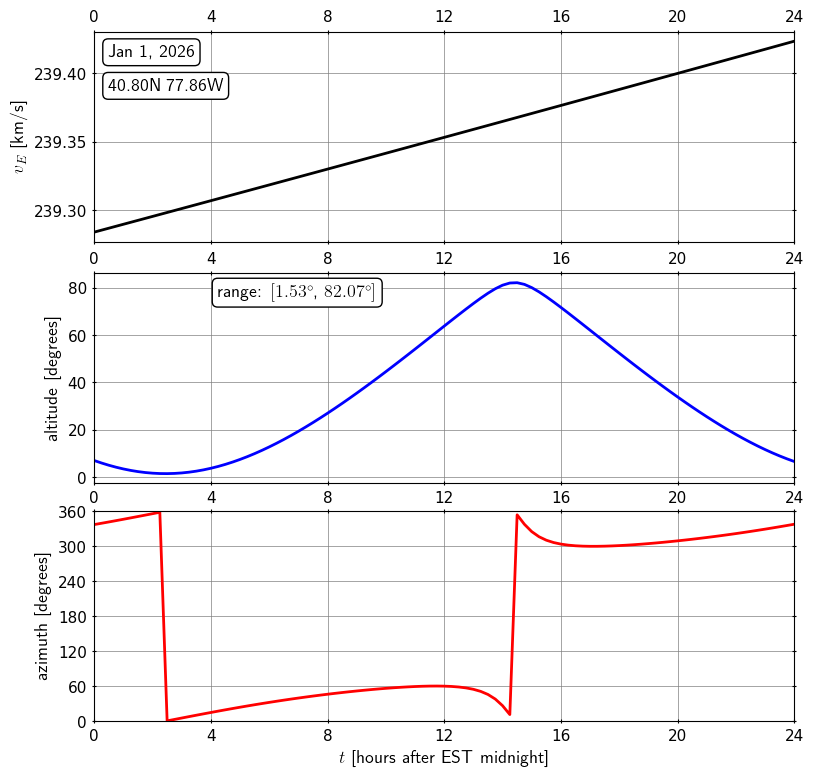

In [8]:
datetext = r'Jan 1, 2026'
placetext = r'40.80N 77.86W'

unisize = 3.5
fig = plt.figure(figsize=[2.0*unisize,unisize])
xlim = [0, 24]

xtix = [4*j for j in range(7)]

ax = fig.add_axes([0,0,1,0.6], xscale='linear', yscale='linear')
ax.set_xticks(xtix)
ax.set_xlim(xlim)
ax.set_yticks([60*j for j in range(7)])
ax.set_ylim([0, 360])
ax.tick_params(axis='both', labelsize=11, direction='inout',
               right=True, top=True, labelbottom=True, labeltop=False)
ax.set_xlabel(r'$t$ [hours after EST midnight]', fontsize=13, usetex=True)
ax.set_ylabel(r'azimuth [degrees]', 
              fontsize=13, usetex=True)

ax.plot(tH, azs, color='red', linewidth=2, linestyle='solid')
ax.grid(color='gray', linestyle='-', linewidth=0.5)

ax2 = fig.add_axes([0,0.68,1,0.6], xscale='linear', yscale='linear')
ax2.set_xticks(xtix)
ax2.set_xlim(xlim)
ax2.tick_params(axis='both', labelsize=11, direction='inout',
                right=True, top=True, labelbottom=True, labeltop=True)
ax2.set_ylabel(r'altitude [degrees]', 
               fontsize=13, usetex=True)
ax2.plot(tH, alts, color='blue', linewidth=2, linestyle='solid')
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

ax3 = fig.add_axes([0,1.37,1,0.6], xscale='linear', yscale='linear')
ax3.set_xticks(xtix)
ax3.set_xlim(xlim)
ax3.tick_params(axis='both', labelsize=11, direction='inout',
                right=True, top=True, labelbottom=False, labeltop=True)
ax3.set_ylabel(r'$v_E$ [km/s]', 
               fontsize=13, usetex=True)
ax3.plot(tH, vEs, color='black', linewidth=2, 
         linestyle='solid')
ax3.grid(color='gray', linestyle='-', linewidth=0.5)

ax2.text(0.29, 0.95, r'range: $[{:.2f}^\circ$, ${:.2f}^\circ]$'.format(alts.min(), alts.max()), 
         horizontalalignment='center',
         verticalalignment='top', fontsize=13, 
         color='black', backgroundcolor='white',
         bbox=dict(boxstyle='round', fc='w'),
         transform=ax2.transAxes, usetex=True)

ax3.text(0.02, 0.94, datetext, 
         horizontalalignment='left',
         verticalalignment='top', fontsize=13, 
         color='black', backgroundcolor='white',
         bbox=dict(boxstyle='round', fc='w'),
         transform=ax3.transAxes, usetex=True)

ax3.text(0.02, 0.78, placetext, 
         horizontalalignment='left',
         verticalalignment='top', fontsize=13, 
         color='black', backgroundcolor='white',
         bbox=dict(boxstyle='round', fc='w'),
         transform=ax3.transAxes, usetex=True)

plt.savefig('out/daily_report.pdf', format="pdf", bbox_inches='tight')

fig.show() 



## Using getExtrema to find DM noon

In [9]:
# find the time of day when the DM wind is lowest in the sky:
DM_midnight = getExtrema(whitmore, midnight, maxAlt=False, n_solns=7, as_datetime=True)
[obj.strftime("%Y-%m-%d %H:%M:%S") for obj in DM_midnight]

['2026-01-01 01:45:18',
 '2026-01-02 01:41:08',
 '2026-01-03 01:36:57',
 '2026-01-04 01:32:48',
 '2026-01-05 01:28:40',
 '2026-01-06 01:24:32',
 '2026-01-07 01:20:25']

In [10]:
# find the time of day when the DM wind is highest in the sky:
DM_noon = getExtrema(whitmore, midnight, maxAlt=True, n_solns=7, as_datetime=True)
[obj.strftime("%Y-%m-%d %H:%M:%S") for obj in DM_noon]

['2026-01-01 13:43:06',
 '2026-01-02 13:38:55',
 '2026-01-03 13:34:45',
 '2026-01-04 13:30:36',
 '2026-01-05 13:26:28',
 '2026-01-06 13:22:21',
 '2026-01-07 13:18:15']

In [11]:
# Track the variation in the DM noon with respect to SIDEREAL time:
dt_list = getExtrema(whitmore, midnight, maxAlt=True, n_solns=366, as_datetime=False)
dt_sidereal = np.array([(dt_list[n] - n*sid_seconds)/3600 for n in range(len(dt_list))])

/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_28426/4242340387.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


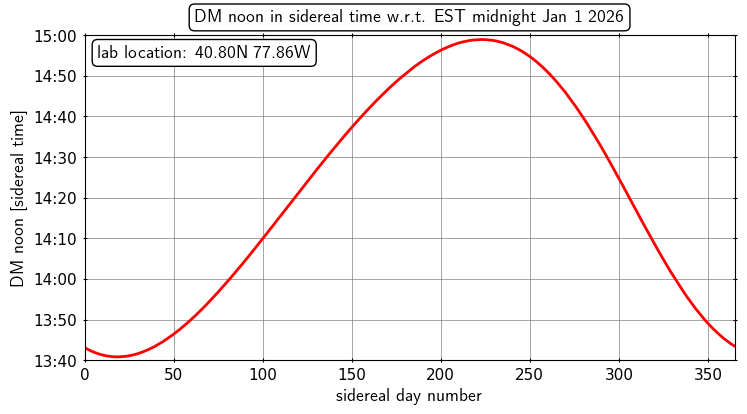

In [12]:
unisize = 3.25
fig = plt.figure(figsize=[2.0*unisize,unisize])

min_t = np.min(dt_sidereal) * 60
max_t = np.max(dt_sidereal) * 60
dx_mins = 10 # interval for xticks, in minutes. integer-valued

tick_min = int(dx_mins * (np.floor(min_t/dx_mins)))
tick_max = int(dx_mins * (np.ceil(max_t/dx_mins)))

xlim = [tick_min, tick_max]
xtix = [j for j in range(tick_min, tick_max+1, dx_mins)]
x_names = []
for t in xtix:
    tm = t % 60
    th = int(round((t - tm)/60))
    lbl = '{}:{:02d}'.format(th, tm)
    x_names += [lbl]


ax = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')
# ax.set_xticks(xtix)
ax.set_yticks(xtix, labels=x_names)
ax.set_ylim(xlim)
# ax.set_yticks([60*j for j in range(7)])
ax.set_xlim([0, 365])
ax.tick_params(axis='both', labelsize=11, direction='inout',
               right=True, top=True, labelbottom=True, labeltop=False)
ax.set_ylabel(r'DM noon [sidereal time]', fontsize=13, usetex=True)
ax.set_xlabel(r'sidereal day number', 
              fontsize=13, usetex=True)

ax.plot([n for n in range(len(dt_sidereal))], dt_sidereal*60, color='red', linewidth=2, linestyle='solid')
ax.grid(color='gray', linestyle='-', linewidth=0.5)

ax.text(0.5, 1.03, r'DM noon in sidereal time w.r.t. EST midnight Jan 1 2026', 
        horizontalalignment='center',
        verticalalignment='bottom', fontsize=13, 
        color='black', backgroundcolor='white',
        bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax.text(0.02, 0.97, r'lab location: '+placetext, 
        horizontalalignment='left',
        verticalalignment='top', fontsize=13, 
        color='black', backgroundcolor='white',
        bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

plt.savefig('out/DMnoon_modulation.pdf', format="pdf", bbox_inches='tight')

fig.show()

In [13]:
dnoon_dt = [dt_list[n] - dt_list[n-1] for n in range(1, len(dt_list))]
longest_day = np.max(dnoon_dt)
shortest_day = np.min(dnoon_dt) 
average_day = np.mean(dnoon_dt)
print('DM Wind Days [s]: (shortest, average, longest)')
print('\t{:.2f} \t{:.2f} \t{:.2f}'.format(shortest_day, average_day, longest_day))
print('longest - shortest: {:.2f} [s]'.format(longest_day-shortest_day))
print('longest - average:  {:.2f} [s]'.format(longest_day-average_day))
print('average - shortest: {:.2f} [s]'.format(average_day-shortest_day))

DM Wind Days [s]: (shortest, average, longest)
	86114.04 	86164.15 	86198.81
longest - shortest: 84.77 [s]
longest - average:  34.66 [s]
average - shortest: 50.11 [s]


# Annual Variation: Boosted Lab Frame 

Using vEt_precise to find vEarth(t) in km/s, then mapping this vector to a point on the sphere. 



## Routine for calculating annual variations in speed, right ascension, and declination

In [14]:
ny_2026 = dts.datetime.fromisoformat('2026-01-01T00:00:00')


vCircs = [220, 230, 238]

days = [n for n in range(0, 366)]
obstimes = []
for n in days:
    obstimes += [ny_2026 + dts.timedelta(days=n)]


d_ras = {}
d_ras_h = {}
d_decs = {}
d_speeds = {}

for vCirc in vCircs:
    wind = Windfinder(obstimes, vCirc=vCirc*km_s)
    RAdec = wind.RAdec 
    RAdec_h = wind.RAdec_h
    d_ras[vCirc] = RAdec[:, 0]
    d_ras_h[vCirc] = RAdec_h[:, 0]
    d_decs[vCirc] = RAdec[:,1]
    d_speeds[vCirc] = wind.speed
    
days = np.array(days)

In [15]:
# Labels for months (n for the first day of each month)

mo_n = []

for mo in range(1, 13):
    first = dts.datetime(2026, mo, 1, 0, 0)
    delta = first - ny_2026
    n_mo = delta.days
    mo_n += [n_mo]

mo = 13
first = dts.datetime(2027, 1, 1, 0, 0)
delta = first - ny_2026
n_mo = delta.days
mo_n += [n_mo]

mo_n = np.array(mo_n)

mo_names = ['Jan `26', 'Feb', 'March', 'April', 
            'May', 'June', 'July', 'Aug', 
            'Sept', 'Oct', 'Nov', 'Dec', 'Jan `27']

# Plots

/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_28426/2257120711.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


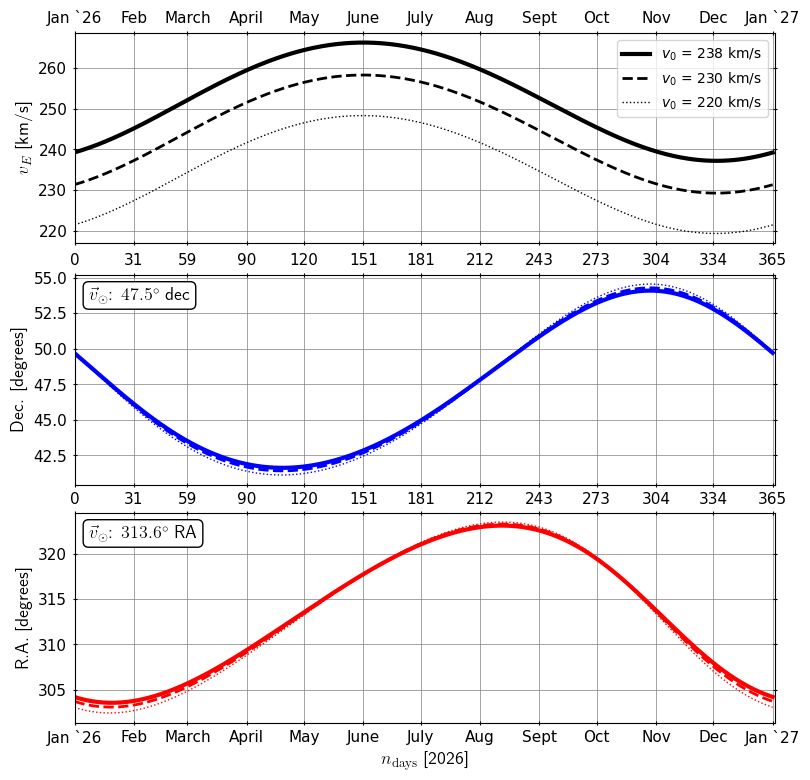

In [16]:
unisize = 3.5
fig = plt.figure(figsize=[2.0*unisize,unisize])
xlim = [0, 366]

# xtix = [30*j for j in range(13)]
xtix = mo_n

ax = fig.add_axes([0,0,1,0.6], xscale='linear', yscale='linear')
ax.set_xticks(xtix, labels=mo_names)
ax.set_xlim(xlim)
ax.tick_params(axis='both', labelsize=11, direction='inout',
               right=True, top=True, labelbottom=True, labeltop=False)
ax.set_xlabel(r'$n_{\rm days}$ [2026]', fontsize=13, usetex=True)
ax.set_ylabel(r'R.A. [degrees]', 
              fontsize=13, usetex=True)

ax.plot(days, d_ras[238], color='red', linewidth=3, linestyle='solid')
ax.plot(days, d_ras[230], color='red', linewidth=2, linestyle='dashed')
ax.plot(days, d_ras[220], color='red', linewidth=1, linestyle='dotted')
# ax.set_ylim([3e-4, 3])
ax.grid(color='gray', linestyle='-', linewidth=0.5)

ax2 = fig.add_axes([0,0.68,1,0.6], xscale='linear', yscale='linear')
ax2.set_xticks(xtix)
ax2.set_xlim(xlim)
ax2.tick_params(axis='both', labelsize=11, direction='inout',
                right=True, top=True, labelbottom=True, labeltop=True)
ax2.set_ylabel(r'Dec. [degrees]', 
               fontsize=13, usetex=True)
ax2.plot(days, d_decs[238], color='blue', linewidth=3, linestyle='solid')
ax2.plot(days, d_decs[230], color='blue', linewidth=2, linestyle='dashed')
ax2.plot(days, d_decs[220], color='blue', linewidth=1, linestyle='dotted')
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

ax3 = fig.add_axes([0,1.37,1,0.6], xscale='linear', yscale='linear')
ax3.set_xticks(xtix, labels=mo_names)
ax3.set_xlim(xlim)
ax3.tick_params(axis='both', labelsize=11, direction='inout',
                right=True, top=True, labelbottom=False, labeltop=True)
ax3.set_ylabel(r'$v_E$ [km/s]', 
               fontsize=13, usetex=True)
ax3.plot(days, d_speeds[238], color='black', linewidth=3, 
         linestyle='solid', label=r'$v_0$ = 238 km/s')
ax3.plot(days, d_speeds[230], color='black', linewidth=2, 
         linestyle='dashed', label=r'$v_0$ = 230 km/s')
ax3.plot(days, d_speeds[220], color='black', linewidth=1, 
         linestyle='dotted', label=r'$v_0$ = 220 km/s')
ax3.grid(color='gray', linestyle='-', linewidth=0.5)
ax3.legend()

ax.text(0.02, 0.94, r'$\vec{v}_\odot$: $313.6^\circ$ RA', 
        horizontalalignment='left',
        verticalalignment='top', fontsize=13, 
        color='black', backgroundcolor='white',
        bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax2.text(0.02, 0.94, r'$\vec{v}_\odot$: $47.5^\circ$ dec', 
         horizontalalignment='left',
         verticalalignment='top', fontsize=13, 
         color='black', backgroundcolor='white',
         bbox=dict(boxstyle='round', fc='w'),
         transform=ax2.transAxes, usetex=True)


fig.show() 



In [17]:
mo_ras = {}
mo_ras_h = {}
mo_decs = {}
sun_RAdec = {}
sun_RAdec_h = {}

for vCirc in vCircs:
    mo_ras[vCirc] = np.array([d_ras[vCirc][j] for j in mo_n[0:-1]])
    mo_ras_h[vCirc] = np.array([d_ras_h[vCirc][j] for j in mo_n[0:-1]])
    mo_decs[vCirc] = np.array([d_decs[vCirc][j] for j in mo_n[0:-1]])

    wind = Windfinder([date], vCirc=vCirc*km_s, at_Sun=True)
    sun_RAdec[vCirc] = wind.RAdec[0]
    sun_RAdec_h[vCirc] = wind.RAdec_h[0]

#

In [18]:
sun_h = int(sun_RAdec_h[238][0])
sun_m = int((sun_RAdec_h[238][0] - sun_h) * 60)
sun_s = (sun_RAdec_h[238][0] - sun_h)*3600 - 60*sun_m  
print('{:02d}:{:02d}:{:.2f}'.format(sun_h, sun_m, sun_s))
# print(sun_RAdec_h[238][0], sun_h + sun_m/60 + sun_s/3600)
sun_rah_lbl = '{:02d}:{:02d}:{:02d}'.format(sun_h, sun_m, int(round(sun_s)))
print(sun_rah_lbl)

20:54:29.15
20:54:29


In [19]:
print(np.min(d_speeds[238]), np.max(d_speeds[238]))

237.18920428037342 266.1966991752039


/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_28426/1014982960.py:71: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


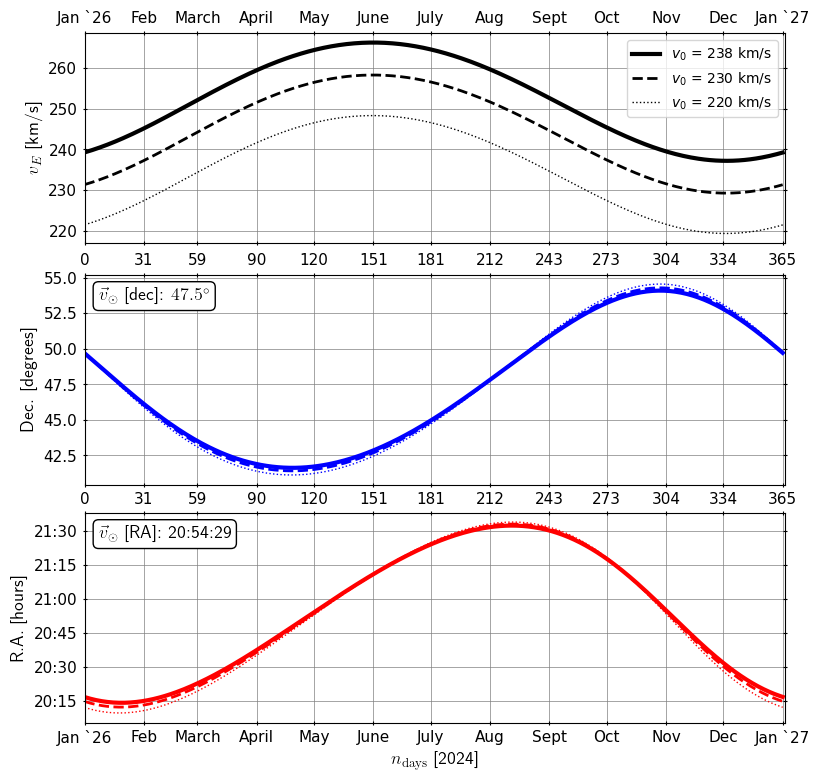

In [20]:
unisize = 3.5
fig = plt.figure(figsize=[2.0*unisize,unisize])
xlim = [0, 366]

# xtix = [30*j for j in range(13)]
xtix = mo_n

rah_tix = [20 + j*0.25 for j in range(7)]
rah_lbl = ['20:00', '20:15', '20:30', '20:45', '21:00', '21:15', '21:30']
ax = fig.add_axes([0,0,1,0.6], xscale='linear', yscale='linear')
ax.set_xticks(xtix, labels=mo_names)
ax.set_xlim(xlim)
ax.set_yticks(rah_tix, labels=rah_lbl)
# ax.set_ylim(xlim)
ax.tick_params(axis='both', labelsize=11, direction='inout',
               right=True, top=True, labelbottom=True, labeltop=False)
ax.set_xlabel(r'$n_{\rm days}$ [2024]', fontsize=13, usetex=True)
ax.set_ylabel(r'R.A. [hours]', 
              fontsize=13, usetex=True)

ax.plot(days, d_ras_h[238], color='red', linewidth=3, linestyle='solid')
ax.plot(days, d_ras_h[230], color='red', linewidth=2, linestyle='dashed')
ax.plot(days, d_ras_h[220], color='red', linewidth=1, linestyle='dotted')
# ax.set_ylim([3e-4, 3])
ax.grid(color='gray', linestyle='-', linewidth=0.5)

ax2 = fig.add_axes([0,0.68,1,0.6], xscale='linear', yscale='linear')
ax2.set_xticks(xtix)
ax2.set_xlim(xlim)
ax2.tick_params(axis='both', labelsize=11, direction='inout',
                right=True, top=True, labelbottom=True, labeltop=True)
ax2.set_ylabel(r'Dec. [degrees]', 
               fontsize=13, usetex=True)
ax2.plot(days, d_decs[238], color='blue', linewidth=3, linestyle='solid')
ax2.plot(days, d_decs[230], color='blue', linewidth=2, linestyle='dashed')
ax2.plot(days, d_decs[220], color='blue', linewidth=1, linestyle='dotted')
ax2.grid(color='gray', linestyle='-', linewidth=0.5)

ax3 = fig.add_axes([0,1.37,1,0.6], xscale='linear', yscale='linear')
ax3.set_xticks(xtix, labels=mo_names)
ax3.set_xlim(xlim)
ax3.tick_params(axis='both', labelsize=11, direction='inout',
                right=True, top=True, labelbottom=False, labeltop=True)
ax3.set_ylabel(r'$v_E$ [km/s]', 
               fontsize=13, usetex=True)
ax3.plot(days, d_speeds[238], color='black', linewidth=3, 
         linestyle='solid', label=r'$v_0$ = 238 km/s')
ax3.plot(days, d_speeds[230], color='black', linewidth=2, 
         linestyle='dashed', label=r'$v_0$ = 230 km/s')
ax3.plot(days, d_speeds[220], color='black', linewidth=1, 
         linestyle='dotted', label=r'$v_0$ = 220 km/s')
ax3.grid(color='gray', linestyle='-', linewidth=0.5)
ax3.legend()

ax.text(0.02, 0.94, r'$\vec{v}_\odot$ [RA]: '+sun_rah_lbl, 
        horizontalalignment='left',
        verticalalignment='top', fontsize=13, 
        color='black', backgroundcolor='white',
        bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax2.text(0.02, 0.94, r'$\vec{v}_\odot$ [dec]: $47.5^\circ$', 
         horizontalalignment='left',
         verticalalignment='top', fontsize=13, 
         color='black', backgroundcolor='white',
         bbox=dict(boxstyle='round', fc='w'),
         transform=ax2.transAxes, usetex=True)

plt.savefig('out/windVelocity_h.pdf', format="pdf", bbox_inches='tight')

fig.show() 



/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_28426/4027383611.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


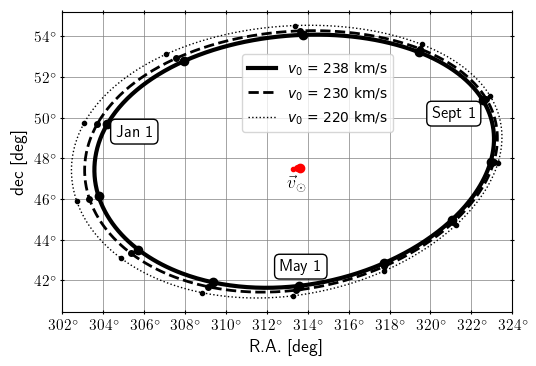

In [21]:
unisize = 3
fig = plt.figure(figsize=[1.5*unisize,unisize])

xtix = [j for j in range(300, 326, 2)]
xtlbl = [r'${}^\circ$'.format(d) for d in xtix]

ytix = [j for j in range(42, 55, 2)]
ytlbl = [r'${}^\circ$'.format(d) for d in ytix]

ax = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')

ax.set_xticks(xtix, labels=xtlbl, usetex=True)
ax.set_yticks(ytix, labels=ytlbl, usetex=True)
ax.set_xlim([302, 324])
# ax.set_yticks(np.array([20 + 0.25*j for j in range(13)]))
ax.tick_params(axis='both', labelsize=11, direction='inout',
               right=True, top=True, labelbottom=True, labeltop=False)
ax.set_xlabel(r'R.A. [deg]', fontsize=13, usetex=True)
ax.set_ylabel(r'dec [deg]', fontsize=13, usetex=True)

ax.plot(d_ras[238], d_decs[238], color='black', linewidth=3, 
        linestyle='solid', label=r'$v_0$ = 238 km/s')
ax.plot(d_ras[230], d_decs[230], color='black', linewidth=2, 
        linestyle='dashed', label=r'$v_0$ = 230 km/s')
ax.plot(d_ras[220], d_decs[220], color='black', linewidth=1, 
        linestyle='dotted', label=r'$v_0$ = 220 km/s')
ax.grid(color='gray', linestyle='-', linewidth=0.5)


ax.plot([sun_RAdec[238][0]], [sun_RAdec[238][1]], color='red', marker='o')
ax.plot(mo_ras[238], mo_decs[238], color='black', marker='o', linestyle='none')

ax.plot([sun_RAdec[230][0]], [sun_RAdec[230][1]], color='red', 
        marker='o', markersize=4)
ax.plot(mo_ras[230], mo_decs[230], color='black', marker='o', 
        linestyle='none', markersize=4)

ax.plot([sun_RAdec[220][0]], [sun_RAdec[220][1]], color='red', 
        marker='o', markersize=3)
ax.plot(mo_ras[220], mo_decs[220], color='black', marker='o', 
        linestyle='none', markersize=3)


ax.text(0.52, 0.43, r'$\vec{v}_\odot$', 
        horizontalalignment='center',
        verticalalignment='center', fontsize=13, 
        color='black', 
        # backgroundcolor='white',
        # bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax.text(0.16, 0.6, r'Jan 1', 
        horizontalalignment='center',
        verticalalignment='center', fontsize=12, 
        color='black', 
        backgroundcolor='white',
        bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax.text(0.53, 0.15, r'May 1', 
        horizontalalignment='center',
        verticalalignment='center', fontsize=12, 
        color='black', 
        backgroundcolor='white',
        bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax.text(0.87, 0.66, r'Sept 1', 
        horizontalalignment='center',
        verticalalignment='center', fontsize=12, 
        color='black', 
        backgroundcolor='white',
        bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax.legend(loc=(0.4, 0.6))



fig.show() 



## With RA in hours, rather than degrees:

/var/folders/9f/0fs4y5917_q6nlh99_p3shbw0000gn/T/ipykernel_28426/3781226518.py:104: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


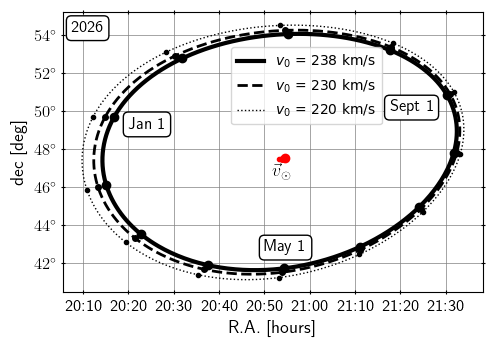

In [22]:
unisize = 2.8
fig = plt.figure(figsize=[1.5*unisize,unisize])

# xtix = [j for j in range(300, 326, 2)]

min_t = np.min(d_ras_h[220]) * 60
max_t = np.max(d_ras_h[220]) * 60
dx_mins = 10 # interval for xticks, in minutes. integer-valued

tick_min = int(dx_mins * (np.floor(min_t/dx_mins)))
tick_max = int(dx_mins * (np.ceil(max_t/dx_mins)))

xlim = [tick_min, tick_max]
xtix = [j for j in range(tick_min, tick_max+1, dx_mins)]
x_names = []
for t in xtix:
    tm = t % 60
    th = int(round((t - tm)/60))
    lbl = '{}:{:02d}'.format(th, tm)
    x_names += [lbl]
xtix = [t/60 for t in xtix]

ytix = [j for j in range(42, 55, 2)]
ytlbl = [r'${}^\circ$'.format(d) for d in ytix]

ax = fig.add_axes([0,0,1,1], xscale='linear', yscale='linear')

ax.set_xticks(xtix, labels=x_names, usetex=True)
ax.set_yticks(ytix, labels=ytlbl, usetex=True)
# ax.set_xlim([302, 324])
# ax.set_yticks(np.array([20 + 0.25*j for j in range(13)]))
ax.tick_params(axis='both', labelsize=12, direction='inout',
               right=True, top=True, labelbottom=True, labeltop=False)
ax.set_xlabel(r'R.A. [hours]', fontsize=13, usetex=True)
ax.set_ylabel(r'dec [deg]', fontsize=13, usetex=True)

ax.plot(d_ras_h[238], d_decs[238], color='black', linewidth=3, 
        linestyle='solid', label=r'$v_0$ = 238 km/s')
ax.plot(d_ras_h[230], d_decs[230], color='black', linewidth=2, 
        linestyle='dashed', label=r'$v_0$ = 230 km/s')
ax.plot(d_ras_h[220], d_decs[220], color='black', linewidth=1, 
        linestyle='dotted', label=r'$v_0$ = 220 km/s')
ax.grid(color='gray', linestyle='-', linewidth=0.5)


ax.plot([sun_RAdec_h[238][0]], [sun_RAdec_h[238][1]], color='red', marker='o')
ax.plot(mo_ras_h[238], mo_decs[238], color='black', marker='o', linestyle='none')

ax.plot([sun_RAdec_h[230][0]], [sun_RAdec_h[230][1]], color='red', 
        marker='o', markersize=4)
ax.plot(mo_ras_h[230], mo_decs[230], color='black', marker='o', 
        linestyle='none', markersize=4)

ax.plot([sun_RAdec_h[220][0]], [sun_RAdec_h[220][1]], color='red', 
        marker='o', markersize=3)
ax.plot(mo_ras_h[220], mo_decs[220], color='black', marker='o', 
        linestyle='none', markersize=3)


ax.text(0.52, 0.43, r'$\vec{v}_\odot$', 
        horizontalalignment='center',
        verticalalignment='center', fontsize=13, 
        color='black', 
        # backgroundcolor='white',
        # bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax.text(0.20, 0.6, r'Jan 1', 
        horizontalalignment='center',
        verticalalignment='center', fontsize=12, 
        color='black', 
        backgroundcolor='white',
        bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax.text(0.53, 0.16, r'May 1', 
        horizontalalignment='center',
        verticalalignment='center', fontsize=12, 
        color='black', 
        backgroundcolor='white',
        bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax.text(0.83, 0.66, r'Sept 1', 
        horizontalalignment='center',
        verticalalignment='center', fontsize=12, 
        color='black', 
        backgroundcolor='white',
        bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax.text(0.02, 0.97, r'2026', 
        horizontalalignment='left',
        verticalalignment='top', fontsize=12, 
        color='black', 
        backgroundcolor='white',
        bbox=dict(boxstyle='round', fc='w'),
        transform=ax.transAxes, usetex=True)

ax.legend(loc=(0.4, 0.6))

plt.savefig('out/sidereal_precession.pdf', format="pdf", bbox_inches='tight')

fig.show() 

